# Turtle Draw - Pipeline de Visão Computacional

Este notebook contém o desenvolvimento da pipeline de visão computacional utilizada no projeto Turtle Draw.

Objetivos:
- Carregar e visualizar a imagem
- Realizar pré-processamento
- Implementar detecção de bordas manualmente
- Extrair contornos
- Preparar os pontos para movimentação no turtlesim

Bibliotecas utilizadas:
- OpenCV (apenas para carregamento da imagem)
- NumPy
- Matplotlib

## 1. Importar Bibliotecas

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregar e Exibir Imagem

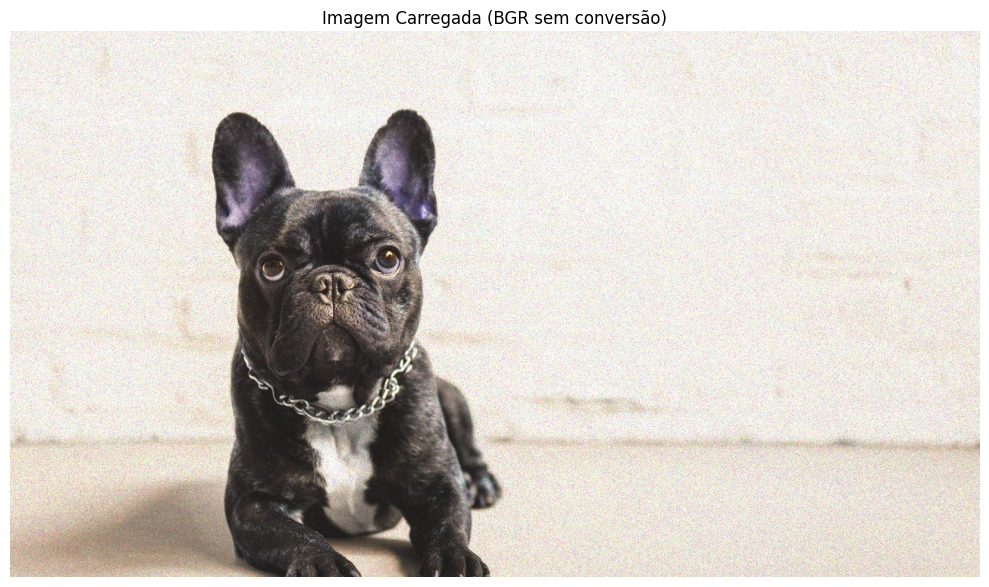

In [7]:
# Carregar imagem
img = cv2.imread("assets/dog.png")

# Mostar a imagem carregada
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title('Imagem Carregada (BGR sem conversão)')
plt.axis('off')
plt.tight_layout()
plt.show()

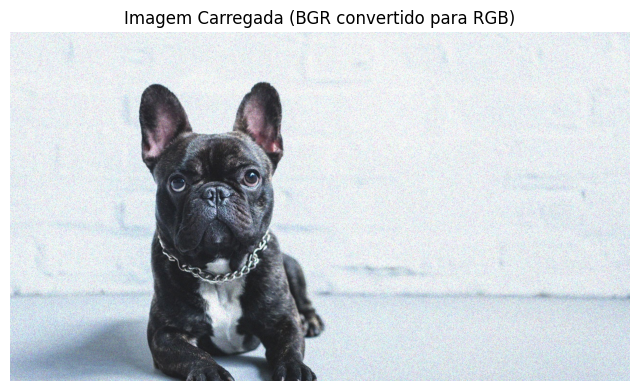

In [ ]:
# Converter BGR para RGB (manualmente)
img_rgb = img[:, :, ::-1]

# Exibir imagem
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title("Imagem Carregada (BGR convertido para RGB)")
plt.axis("off")
plt.show()

In [9]:
print(f"Shape: {img_rgb.shape}")
print(f"Tipo de dados: {img_rgb.dtype}")

Shape: (720, 1280, 3)
Tipo de dados: uint8


## 3. Pré-processamento

O pré-processamento tem como objetivo preparar a imagem para as etapas posteriores da pipeline de visão computacional, reduzindo informações desnecessárias e facilitando a detecção de bordas.

Imagens originais normalmente possuem ruídos, variações de iluminação, texturas e detalhes que podem dificultar a identificação correta dos contornos principais. Dessa forma, aplicar transformações antes da detecção de bordas ajuda a simplificar a imagem e destacar as estruturas mais importantes.

Nesta etapa, serão realizadas transformações para reduzir a complexidade da imagem e melhorar a qualidade da extração de contornos.

### 3.1 Conversão para Grayscale

A imagem carregada originalmente está no formato RGB, composto por três canais de cor: vermelho (Red), verde (Green) e azul (Blue).

Entretanto, para a detecção de bordas, as informações de cor não são essenciais, sendo o mais importante identificar mudanças de intensidade entre regiões da imagem. Por isso, a imagem foi convertida para **grayscale (tons de cinza)**, simplificando a imagem, reduzindo a complexidade do processamento, reduzindo ruídos de cor e facilitando a análise posterior.

Na imagem em grayscale, cada pixel passa a possuir apenas um valor de intensidade, variando entre preto (0) e branco (255).

A conversão foi implementada manualmente utilizando uma média ponderada dos canais RGB. A fórmula utilizada foi:

> `Gray = 0.299R + 0.587G + 0.114B`

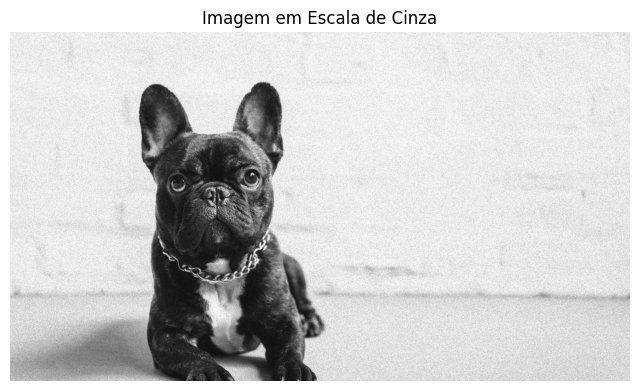

In [14]:
# 3 canais RBG da imagem multiplicados pelos pesos e somados para obter a intensidade de cinza
img_gray = np.dot(img_rgb[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

# Exibir imagem em escala de cinza
plt.figure(figsize=(8, 8))
plt.imshow(img_gray, cmap='gray')
plt.title("Imagem em Escala de Cinza")
plt.axis("off")
plt.show()

In [15]:
print(f"Shape da imagem grayscale: {img_gray.shape}")
print(f"Tipo de dados: {img_gray.dtype}")

Shape da imagem grayscale: (720, 1280)
Tipo de dados: uint8


Após a conversão, a imagem mantém as informações estruturais necessárias para a detecção de bordas, porém com menor complexidade computacional.